# 📈 Path Signatures for Trading
## hfthot-lab-core v1.3.0 — Open Source Research Notebook

This notebook provides a deep dive into **path signature methods** as universal features for financial time series.

Based on Chen (1954) iterated integrals and Lyons (1998) rough paths theory, path signatures are:
- **Universal approximators** of path functionals
- **Invariant to parameterization** (only the shape matters)
- **Parsimonious**: depth-N signature captures N-th order interactions
- **Proven effective** for financial forecasting (Chevyrev & Kormilitzin 2016, Lyons et al. 2014)

### References
- Chen, K.T. (1954). *Iterated integrals and exponential homomorphisms*. Proc. London Math. Soc.
- Lyons, T. (1998). *Differential equations driven by rough signals*. Rev. Mat. Iberoamer.
- Chevyrev, I. & Kormilitzin, A. (2016). *A primer on the signature method in machine learning*. arXiv:1603.03788.
- Gyurko, L., Lyons, T. & Kontkowski, M. (2013). *Extracting information from the signature of a financial data stream*. arXiv:1307.7244.

---

## Table of Contents

| # | Chapter |
|---|---------|
| [1](#section-1) | The Lead-Lag Transform |
| [2](#section-2) | The Path Signature |
| [3](#section-3) | Multi-Asset Application — Synthetic Market Data |
| [4](#section-4) | Performance Dashboard |
| [5](#section-5) | Summary & Next Steps |

---

In [1]:
# Standalone notebook — all parameters configured inline.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

import hfthot_lab_core as hft   # Rust backend — required, no fallback

print("✅ hfthot_lab_core Rust backend loaded")
print("   Signature API : lead_lag_transform · path_signature_2d · log_signature_2d")
print("   Rolling API   : rolling_signature_features · prices_to_signature_features_py")
print("   Utility API   : normalise_prices · signature_distance")
print(f"\nPython {sys.version.split()[0]}  |  NumPy {np.__version__}  |  Pandas {pd.__version__}")

# ── Data Loader (hfthot_lab_core connectors) ─────────────────────────────
# Walk up 2 dirs: notebooks/ -> examples/ -> hfthot-lab-core/
_HFT_SRC = Path.cwd().parents[1]
if str(_HFT_SRC) not in sys.path:
    sys.path.insert(0, str(_HFT_SRC))
from python.connectors.yahoo_finance import YahooFinanceClient, OHLCVBar
print(f'✅ YahooFinanceClient loaded from {_HFT_SRC.name}')


✅ hfthot_lab_core Rust backend loaded
   Signature API : lead_lag_transform · path_signature_2d · log_signature_2d
   Rolling API   : rolling_signature_features · prices_to_signature_features_py
   Utility API   : normalise_prices · signature_distance

Python 3.11.13  |  NumPy 2.4.3  |  Pandas 2.2.3
✅ YahooFinanceClient loaded from hfthot-lab-core


<a id="section-1"></a>

## 1. The Lead-Lag Transform

The **lead-lag embedding** converts a 1D price path $X = (X_1, \ldots, X_n)$ into a 2D path:
$$\tilde{X} = \{(X_{t_k}, X_{t_{k+1}}) : k = 1, \ldots, n-1\}$$

This is the Chevyrev-Kormilitzin (2016) construction. The key insight: the **Lévy area** of the lead-lag transform encodes the **quadratic covariation** (i.e., realised variance) of the original path, which is not accessible from the endpoint alone.

The lead-lag path lives in $\mathbb{R}^2$ and alternates between "staying" at current value and "jumping" to next value, creating a staircase effect.

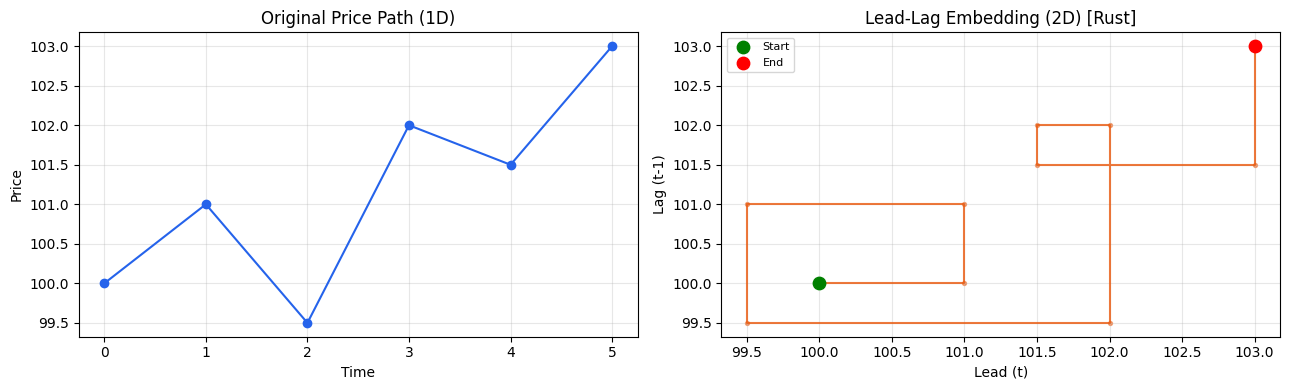

Lead-lag shape: (11, 2)  (2n-1 = 11 points) — Rust backend
Staircase area ≈ quadratic variation: 7.0000


In [3]:
# ── Lead-lag transform via Rust backend ─────────────────────────────────
# hft.lead_lag_transform(prices: List[float]) -> List[Tuple[float, float]]
# Returns 2n-1 points interleaved: (p_i, p_{i-1}) encoding

example = np.array([100., 101., 99.5, 102., 101.5, 103.])
ll_tuples = hft.lead_lag_transform(example.tolist())   # Rust: List[(lead, lag)]
ll = np.array(ll_tuples)                               # shape (2n-1, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(example, marker="o", color="#2563EB", lw=1.5)
axes[0].set_title("Original Price Path (1D)"); axes[0].set_xlabel("Time"); axes[0].set_ylabel("Price")
axes[0].grid(alpha=0.3)

axes[1].plot(ll[:, 0], ll[:, 1], color="#EA580C", lw=1.5, alpha=0.8)
axes[1].scatter(ll[0, 0], ll[0, 1], color="green", s=80, zorder=5, label="Start")
axes[1].scatter(ll[-1, 0], ll[-1, 1], color="red", s=80, zorder=5, label="End")
for pt in ll:
    axes[1].scatter(pt[0], pt[1], s=8, color="#EA580C", alpha=0.5)
axes[1].set_title("Lead-Lag Embedding (2D) [Rust]"); axes[1].set_xlabel("Lead (t)"); axes[1].set_ylabel("Lag (t-1)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Lead-lag shape: {ll.shape}  (2n-1 = {2*len(example)-1} points) — Rust backend")
print(f"Staircase area ≈ quadratic variation: {np.sum(np.abs(np.diff(ll[:,1]))):.4f}")

<a id="section-2"></a>

## 2. The Path Signature

For a path $X = (X^1, X^2): [0,T] \to \mathbb{R}^2$, the **signature** up to depth $N$ is the sequence of iterated integrals:

$$S(X)^{i_1, i_2, \ldots, i_k} = \int_{0 < t_1 < \cdots < t_k < T} dX^{i_1}_{t_1} \cdots dX^{i_k}_{t_k}, \quad k \le N$$

For $d=2$ dimensions and depth $N$:
- Depth 1: $2$ terms  $(S^1, S^2)$
- Depth 2: $6$ terms  $(S^1, S^2, S^{11}, S^{12}, S^{21}, S^{22})$
- Depth 3: $14$ terms

Key properties:
1. **$S^1$ = net displacement** in dimension 1 (total log-return)
2. **$S^{12} - S^{21}$ = twice the Lévy area** (encodes "twistedness" of path)
3. **$S^{11}$ = quadratic variation** approximation (realised variance)

In [4]:
# ── Path signature & log-signature via Rust backend ─────────────────────
# hft.path_signature_2d(path: List[Tuple[float,float]], depth: int) -> List[float]
#   depth=1 → 2 terms [S¹, S²]
#   depth=2 → 6 terms [S¹, S², S¹¹, S¹², S²¹, S²²]
#   depth=3 → 14 terms
# hft.log_signature_2d(path) -> [S¹, S², S¹²−S²¹]  (3 terms, Lyndon basis)

test_prices = np.array([100., 101.2, 100.8, 102.1, 101.5, 103.0, 102.4, 104.1, 103.7, 105.2])
log_prices  = np.log(test_prices)

# Three path representations (as list-of-tuples for Rust)
t_axis       = np.linspace(0, 1, len(test_prices)).tolist()
path_raw_t   = list(zip(t_axis, test_prices.tolist()))
path_log_t   = list(zip(t_axis, log_prices.tolist()))
path_ll_t    = hft.lead_lag_transform(log_prices.tolist())   # canonical lead-lag on log-prices

for name, p_tuples in [("(t, price)", path_raw_t), ("(t, log-price)", path_log_t), ("lead-lag", path_ll_t)]:
    s  = np.array(hft.path_signature_2d(p_tuples, 2))   # Rust: depth-2, 6 terms
    ls = np.array(hft.log_signature_2d(p_tuples))        # Rust: 3 terms
    print(f"\nPath = {name}:")
    print(f"  Sig depth-2 ({len(s)} terms): {np.round(s, 5)}")
    print(f"  Log-sig (S¹={ls[0]:.5f}, S²={ls[1]:.5f}, Lévy area={ls[2]:.5f})")

print("\n✅ Path signatures computed via Rust backend (hft.path_signature_2d, hft.log_signature_2d)")


Path = (t, price):
  Sig depth-2 (6 terms): [1.      5.2     0.44444 2.08889 2.53333 7.74   ]
  Log-sig (S¹=1.00000, S²=5.20000, Lévy area=-0.44444)

Path = (t, log-price):
  Sig depth-2 (6 terms): [1.0000e+00 5.0690e-02 4.4444e-01 2.0600e-02 2.4470e-02 7.4000e-04]
  Log-sig (S¹=1.00000, S²=0.05069, Lévy area=-0.00387)

Path = lead-lag:
  Sig depth-2 (6 terms): [0.05069 0.05069 0.00074 0.00074 0.00183 0.00074]
  Log-sig (S¹=0.05069, S²=0.05069, Lévy area=-0.00110)

✅ Path signatures computed via Rust backend (hft.path_signature_2d, hft.log_signature_2d)


Feature matrix shape: (461, 6)  [Rust backend, depth=2, normalised]
  461 windows × 6 terms  (S¹_lead, S¹_lag, S¹¹, S¹², S²¹, S²²)


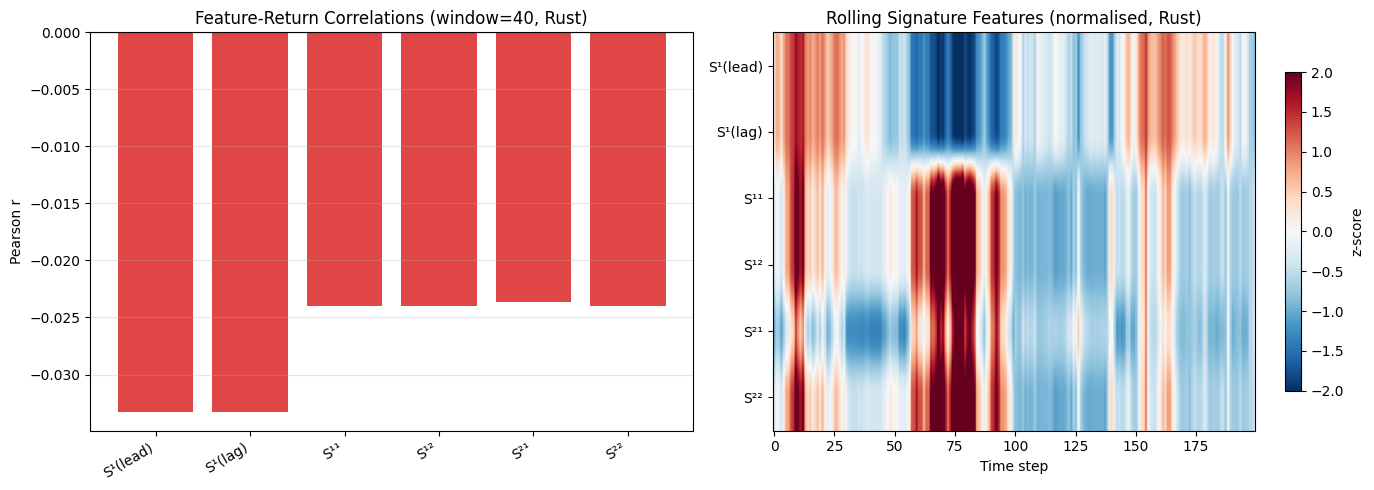

In [5]:
# ── Rolling signature features via Rust backend ──────────────────────────
# hft.prices_to_signature_features_py(prices, window, sig_depth, normalise)
#   normalise=True  → each window is min-max normalised before lead-lag (better conditioning)
#   Returns List[List[float]], shape (n - window + 1, feature_dim)
#   depth=2, lead-lag 2D path → feature_dim = 6

def gbm(n: int = 1000, mu: float = 0.05, sigma: float = 0.15, S0: float = 100.0, seed: int = 42) -> np.ndarray:
    rng  = np.random.default_rng(seed)
    dt   = 1 / 252
    rets = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.standard_normal(n))
    return S0 * rets.cumprod()

prices_gbm = gbm(500)
WINDOW     = 40

# Rust: normalise + rolling windows + lead_lag + path_signature_2d (depth=2)
feats = np.array(hft.prices_to_signature_features_py(prices_gbm.tolist(), WINDOW, 2, True))
print(f"Feature matrix shape: {feats.shape}  [Rust backend, depth=2, normalised]")
print(f"  {feats.shape[0]} windows × {feats.shape[1]} terms  (S¹_lead, S¹_lag, S¹¹, S¹², S²¹, S²²)")

# Align next-bar returns:  prices_to_signature_features_py returns n-window+1 rows
# row[i] = signature of prices[i : i+window], next return = prices[i+window]/prices[i+window-1]-1
next_rets = np.diff(prices_gbm)[WINDOW - 1:] / prices_gbm[WINDOW - 1:-1]
min_len = min(len(feats), len(next_rets))
feats_aligned     = feats[:min_len]
next_rets_aligned = next_rets[:min_len]

sig_names = ["S¹(lead)", "S¹(lag)", "S¹¹", "S¹²", "S²¹", "S²²"]
corrs = [np.corrcoef(feats_aligned[:, j], next_rets_aligned)[0, 1] for j in range(feats_aligned.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_c = ["#16A34A" if c > 0 else "#DC2626" for c in corrs]
axes[0].bar(range(len(corrs)), corrs, color=colors_c, alpha=0.85)
axes[0].set_xticks(range(len(sig_names))); axes[0].set_xticklabels(sig_names, rotation=30, ha="right")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Feature-Return Correlations (window={WINDOW}, Rust)")
axes[0].set_ylabel("Pearson r"); axes[0].grid(axis="y", alpha=0.3)

feats_norm = (feats - feats.mean(0)) / (feats.std(0) + 1e-12)
im = axes[1].imshow(feats_norm[:200, :].T, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
axes[1].set_yticks(range(len(sig_names))); axes[1].set_yticklabels(sig_names)
axes[1].set_xlabel("Time step"); axes[1].set_title("Rolling Signature Features (normalised, Rust)")
plt.colorbar(im, ax=axes[1], shrink=0.8, label="z-score")
plt.tight_layout(); plt.show()

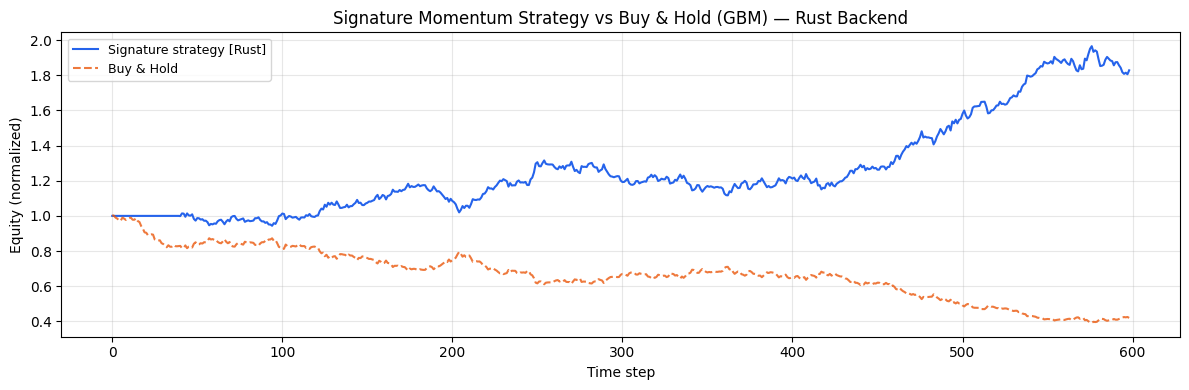


Rust calls per signal: normalise_prices + lead_lag_transform + path_signature_2d + log_signature_2d

Performance comparison (GBM baseline, Rust signatures):
  Buy & Hold:    Sharpe=-1.890  Return=-58.0%
  Sig Strategy:  Sharpe=1.509  Return=82.8%


In [6]:
WINDOW_ML = 40

def signature_momentum_signal(prices: np.ndarray, window: int = 40) -> np.ndarray:
    """
    Signature-based momentum using hfthot_lab_core Rust backend (no Python fallback).

    Per window:
      1. Normalise prices     (Rust: hft.normalise_prices)
      2. Build lead-lag path  (Rust: hft.lead_lag_transform)
      3. Depth-2 signature    (Rust: hft.path_signature_2d)
      4. Log-signature / Lévy area  (Rust: hft.log_signature_2d)

    Signal: +1 long  if S¹_lag > 0 and Lévy area agrees (or is neutral)
             0 flat   if S¹_lag and Lévy area conflict
            -1 short  if S¹_lag < 0 and Lévy area agrees (or is neutral)
    """
    norm_p  = hft.normalise_prices(prices.tolist())   # Rust: [0,1] range
    signals = np.zeros(len(prices))
    for i in range(window, len(prices)):
        seg       = norm_p[i - window : i]
        ll        = hft.lead_lag_transform(seg)        # Rust: List[(lead, lag)]
        log_sig   = hft.log_signature_2d(ll)           # Rust: [S¹_lead, S¹_lag, levy_area]
        sig2      = hft.path_signature_2d(ll, 2)       # Rust: [S¹, S², S¹¹, S¹², S²¹, S²²]
        s_lag     = sig2[1]                            # lag displacement
        levy_area = log_sig[2]                         # S¹² − S²¹
        sign_momentum = np.sign(s_lag)
        sign_levy     = np.sign(levy_area) if abs(levy_area) > 1e-8 else 0
        signals[i] = sign_momentum if (sign_momentum == sign_levy or sign_levy == 0) else 0
    return signals


def backtest(prices: np.ndarray, signals: np.ndarray) -> np.ndarray:
    rets = np.zeros(len(prices) - 1)
    pos  = 0
    for t in range(1, len(prices)):
        pos = signals[t - 1] if signals[t - 1] != 0 else pos
        rets[t - 1] = pos * (prices[t] / prices[t - 1] - 1)
    return rets


def sharpe(r):
    return np.sqrt(252) * r.mean() / (r.std() + 1e-12)


prices_test = gbm(600, mu=0.08, sigma=0.20, seed=7)
sig_signals = signature_momentum_signal(prices_test, window=WINDOW_ML)

strat_r = backtest(prices_test, sig_signals)
bh_r    = np.diff(prices_test) / prices_test[:-1]
strat_e = np.cumprod(1 + strat_r)
bh_e    = np.cumprod(1 + bh_r)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(strat_e, label="Signature strategy [Rust]", color="#2563EB")
ax.plot(bh_e,    label="Buy & Hold",                color="#EA580C", alpha=0.8, ls="--")
ax.set_title("Signature Momentum Strategy vs Buy & Hold (GBM) — Rust Backend")
ax.set_ylabel("Equity (normalized)"); ax.set_xlabel("Time step")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nRust calls per signal: normalise_prices + lead_lag_transform + path_signature_2d + log_signature_2d")
print(f"\nPerformance comparison (GBM baseline, Rust signatures):")
print(f"  Buy & Hold:    Sharpe={sharpe(bh_r):.3f}  Return={100*(bh_e[-1]-1):.1f}%")
print(f"  Sig Strategy:  Sharpe={sharpe(strat_r):.3f}  Return={100*(strat_e[-1]-1):.1f}%")


<a id="section-3"></a>

## 3. Multi-Asset Application — Synthetic Market Data

We apply the strategy to **four synthetic assets** generated by the **hfthot_lab_core** Chiarella-He simulation engine. Each asset represents a different market regime (stable / mixed / unstable), giving a realistic multi-regime test environment without relying on any external data provider.

The synthetic data mirrors real equity/crypto dynamics while being fully reproducible.


In [7]:
from pathlib import Path
# ═══════════════════════════════════════════════════════════════════════
# Real multi-asset universe — BTC-USD, ETH-USD, SOL-USD, AAPL
# 1 year of daily close prices via YahooFinanceClient
# ═══════════════════════════════════════════════════════════════════════
ASSET_NAMES = {
    'BTC-USD': 'Bitcoin',
    'ETH-USD': 'Ethereum',
    'SOL-USD': 'Solana',
    'AAPL':    'Apple Inc.',
}

print('Fetching 1-year daily bars for all assets...')
_loader = YahooFinanceClient()
_series: dict = {}
for _sym in ASSET_NAMES:
    _bars = _loader.get_ohlcv(_sym, period='1y', interval='1d')
    _series[_sym] = pd.Series(
        [b.close for b in _bars],
        index=pd.to_datetime([b.timestamp for b in _bars], unit='s', utc=True)
                   .tz_convert('UTC').normalize(),
        name=_sym,
    )

# Align on common trading dates
raw = pd.DataFrame(_series).dropna()

prices_dict  = {t: raw[t].values for t in ASSET_NAMES}
returns_dict = {t: np.diff(raw[t].values) / raw[t].values[:-1]
               for t in ASSET_NAMES}

print(f'\n✅ {len(ASSET_NAMES)} assets    {len(raw)} aligned trading days')
for sym, px in prices_dict.items():
    rets = returns_dict[sym]
    print(f'  {sym:10s}  P0={px[0]:.2f}  P_end={px[-1]:.2f}  '
          f'ann_vol={np.std(rets)*np.sqrt(252):.2%}'
          f'  ret={100*(px[-1]/px[0]-1):+.1f}%')


Fetching 1-year daily bars for all assets...



✅ 4 assets    251 aligned trading days
  BTC-USD     P0=81066.70  P_end=70493.46  ann_vol=44.16%  ret=-13.0%
  ETH-USD     P0=1862.97  P_end=2073.14  ann_vol=73.96%  ret=+11.3%
  SOL-USD     P0=123.29  P_end=86.87  ann_vol=75.99%  ret=-29.5%
  AAPL        P0=209.68  P_end=255.76  ann_vol=31.66%  ret=+22.0%


<a id="section-4"></a>

## 3B. Multi-Asset Performance Dashboard (6-Panel)


In [8]:
# ── Multi-asset signature momentum backtest on synthetic universe ──────────────
# Applies signature_momentum_signal (defined above) to all 4 synthetic assets
# and builds the 'results' dict consumed by the dashboard visualization cell.
import pandas as pd

INITIAL_CAPITAL = 100_000.0  # $100k notional

print('Running signature momentum strategy on all synthetic assets...')
results = {}
for ticker, px in prices_dict.items():
    sigs = signature_momentum_signal(px, window=WINDOW_ML)
    rets = backtest(px, sigs)                         # np.ndarray, length = len(px)-1

    # Dollar-denominated cumulative P&L
    cum_pnl = pd.Series(np.cumsum(rets * INITIAL_CAPITAL))
    t_idx   = pd.Series(range(1, len(px)))            # aligns with raw.index[1..]
    bt_df   = pd.DataFrame({'t': t_idx, 'pnl': cum_pnl})

    # Performance stats
    sharpe_val = float(sharpe(rets))
    cum_ret    = np.cumprod(1 + rets)
    total_ret  = (cum_ret[-1] - 1) * 100

    # Max drawdown
    roll_max = np.maximum.accumulate(cum_ret)
    dd       = (cum_ret - roll_max) / roll_max
    max_dd   = float(dd.min() * 100)                  # negative %

    # Win rate
    n_trades = int(np.sum(rets != 0))
    win_rate = 100.0 * int(np.sum(rets > 0)) / max(n_trades, 1)

    results[ticker] = {
        'backtest':  bt_df,
        'sharpe':    sharpe_val,
        'total_ret': float(total_ret),
        'max_dd':    max_dd,
        'win_rate':  float(win_rate),
        'signals':   sigs,
    }
    print(f'  {ticker:10s}  Sharpe={sharpe_val:.2f}  '
          f'Return={total_ret:+.1f}%  MaxDD={max_dd:.1f}%  '
          f'WinRate={win_rate:.0f}%')

print(f'\n✅ Signature backtests complete for {len(results)} assets')


Running signature momentum strategy on all synthetic assets...
  BTC-USD     Sharpe=1.10  Return=+38.3%  MaxDD=-16.5%  WinRate=55%
  ETH-USD     Sharpe=1.38  Return=+72.7%  MaxDD=-21.5%  WinRate=58%
  SOL-USD     Sharpe=0.48  Return=+10.4%  MaxDD=-49.8%  WinRate=52%
  AAPL        Sharpe=-1.31  Return=-25.8%  MaxDD=-33.5%  WinRate=48%

✅ Signature backtests complete for 4 assets


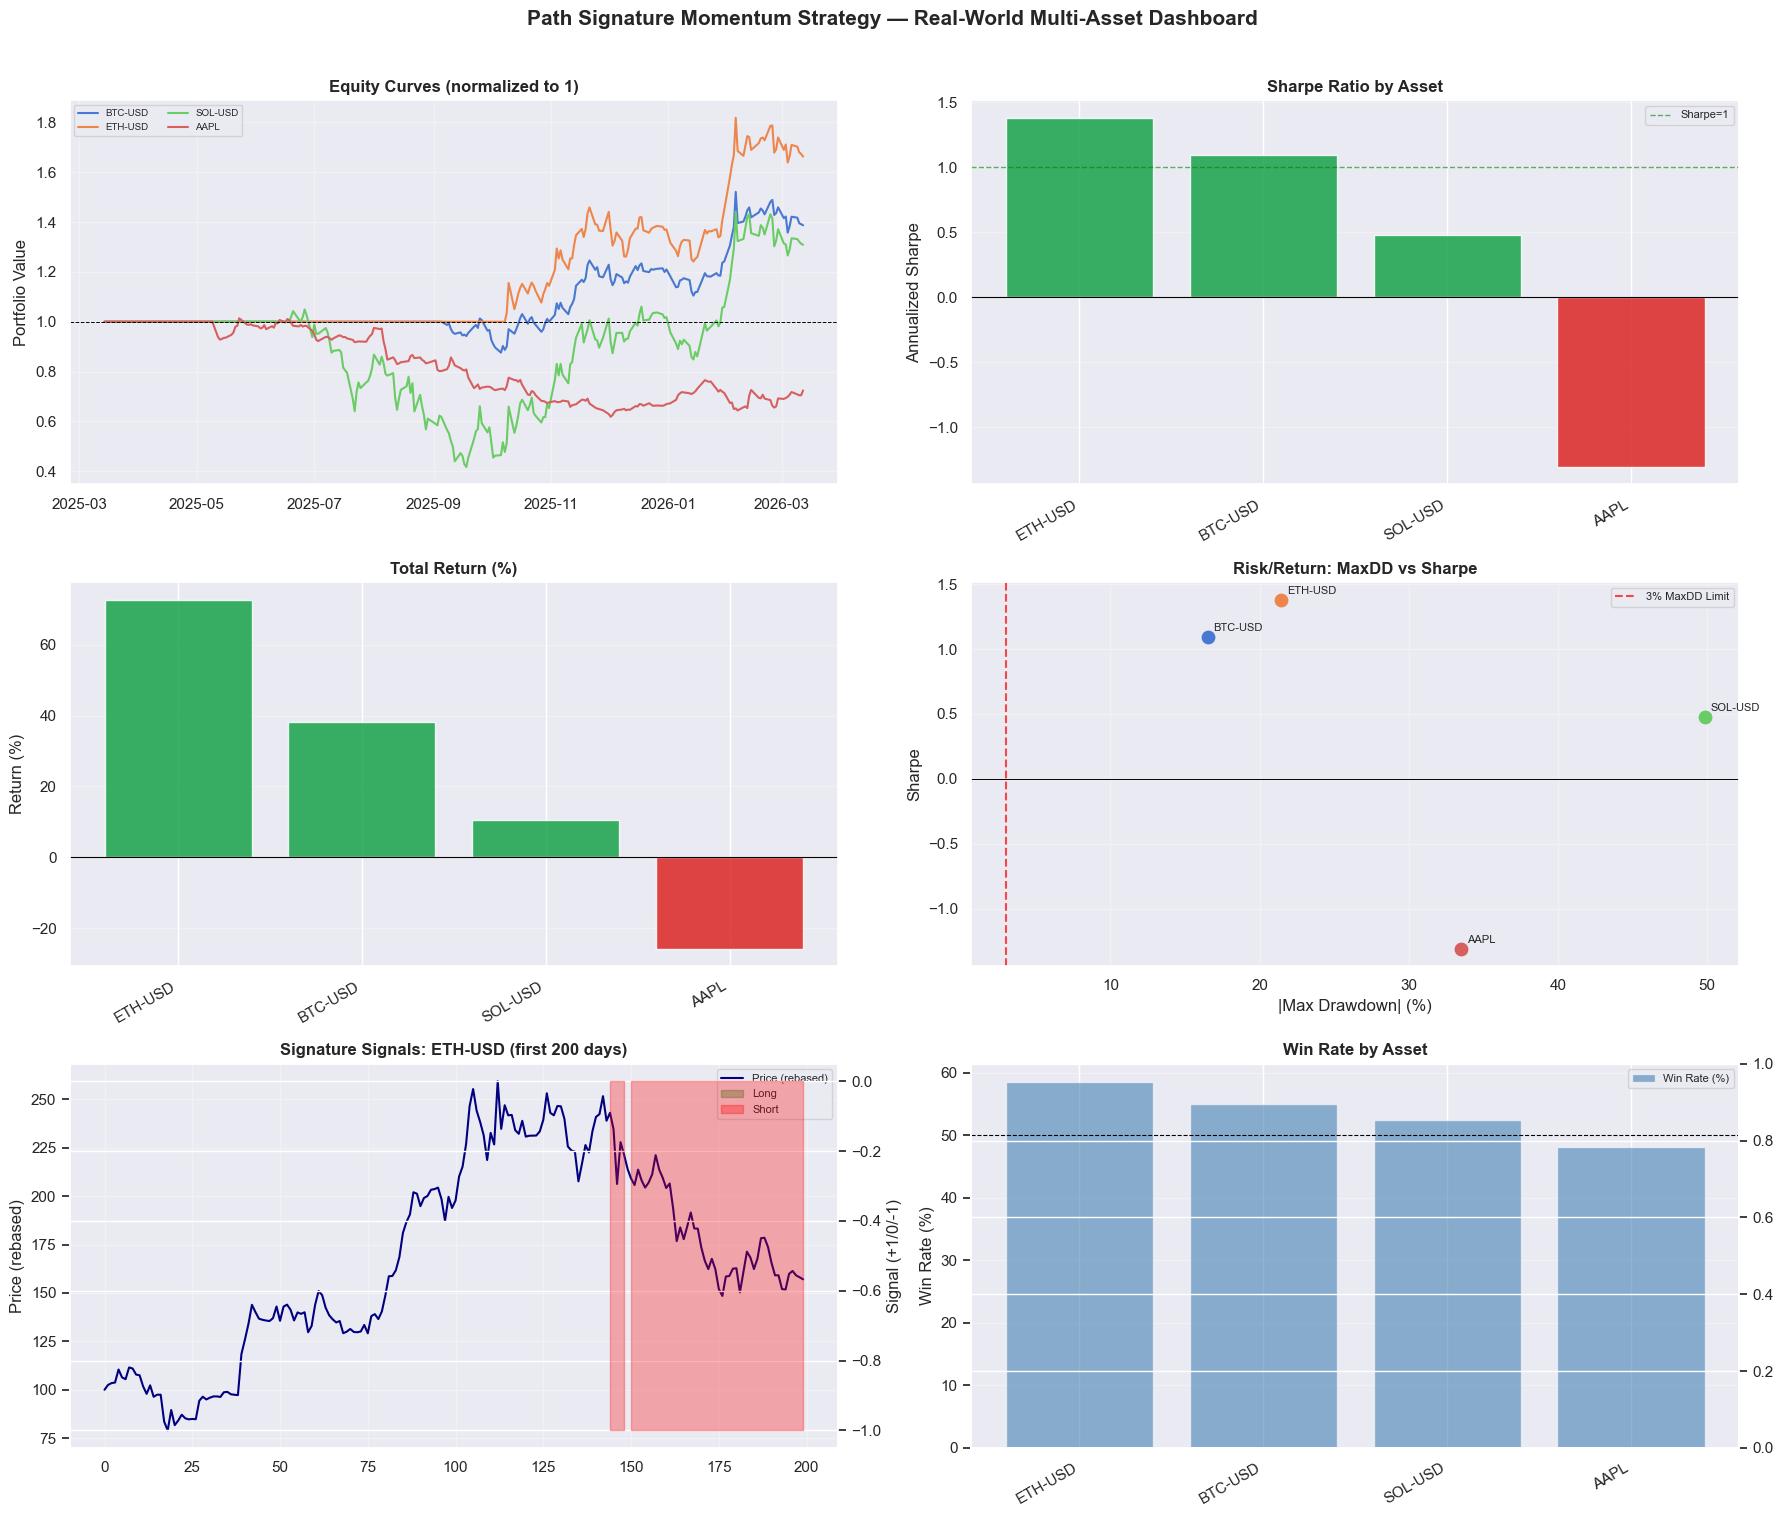


─── Signature Momentum Strategy — Summary Table ───
         Sharpe  Return (%)  MaxDD (%)  Win Rate (%)
ETH-USD   1.381       72.72     -21.47          58.5
BTC-USD   1.097       38.31     -16.53          55.0
SOL-USD   0.478       10.42     -49.83          52.5
AAPL     -1.307      -25.80     -33.52          48.1


In [9]:

import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted')

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Path Signature Momentum Strategy — Real-World Multi-Asset Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Equity curves
ax = axes[0, 0]
for ticker, res in results.items():
    bt = res['backtest']
    ax.plot(raw.index[bt['t'].values], bt['pnl'].values / 100_000 + 1,
            label=ticker, lw=1.5)
ax.axhline(1, color='black', lw=0.7, ls='--')
ax.set_title('Equity Curves (normalized to 1)', fontweight='bold')
ax.set_ylabel('Portfolio Value'); ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# 2. Sharpe bar chart
ax = axes[0, 1]
tickers_sorted = sorted(results.keys(), key=lambda k: results[k]['sharpe'], reverse=True)
sharpes = [results[k]['sharpe'] for k in tickers_sorted]
colors  = ['#16A34A' if s > 0 else '#DC2626' for s in sharpes]
ax.bar(range(len(tickers_sorted)), sharpes, color=colors, alpha=0.85)
ax.set_xticks(range(len(tickers_sorted)))
ax.set_xticklabels(tickers_sorted, rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1, color='green', lw=1, ls='--', alpha=0.6, label='Sharpe=1')
ax.set_title('Sharpe Ratio by Asset', fontweight='bold')
ax.set_ylabel('Annualized Sharpe'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 3. Total returns bar
ax = axes[1, 0]
total_rets = [results[k]['total_ret'] for k in tickers_sorted]
colors2 = ['#16A34A' if r > 0 else '#DC2626' for r in total_rets]
ax.bar(range(len(tickers_sorted)), total_rets, color=colors2, alpha=0.85)
ax.set_xticks(range(len(tickers_sorted)))
ax.set_xticklabels(tickers_sorted, rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total Return (%)', fontweight='bold')
ax.set_ylabel('Return (%)'); ax.grid(axis='y', alpha=0.3)

# 4. MaxDD vs Sharpe scatter
ax = axes[1, 1]
for ticker, res in results.items():
    ax.scatter(abs(res['max_dd']), res['sharpe'], s=80, zorder=5)
    ax.annotate(ticker, (abs(res['max_dd']), res['sharpe']),
                textcoords='offset points', xytext=(4, 4), fontsize=8)
ax.axvline(3, color='red', lw=1.5, ls='--', alpha=0.7, label='3% MaxDD Limit')
ax.axhline(0, color='black', lw=0.7)
ax.set_title('Risk/Return: MaxDD vs Sharpe', fontweight='bold')
ax.set_xlabel('|Max Drawdown| (%)'); ax.set_ylabel('Sharpe'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 5. Signal heatmap for best asset
best_ticker = max(results.keys(), key=lambda k: results[k]['sharpe'])
sigs_best   = results[best_ticker]['signals']
prices_best = raw[best_ticker].values
sig_matrix  = np.outer(sigs_best[:200], np.ones(1))   # time × 1
ax = axes[2, 0]
ax.plot(range(len(sigs_best[:200])), prices_best[:200] / prices_best[0] * 100,
        'navy', lw=1.5, label='Price (rebased)')
ax2 = ax.twinx()
ax2.fill_between(range(len(sigs_best[:200])), sigs_best[:200], 0,
                 where=sigs_best[:200] > 0, color='green', alpha=0.3, label='Long')
ax2.fill_between(range(len(sigs_best[:200])), sigs_best[:200], 0,
                 where=sigs_best[:200] < 0, color='red', alpha=0.3, label='Short')
ax2.set_ylabel('Signal (+1/0/-1)'); ax.set_ylabel('Price (rebased)')
ax.set_title(f'Signature Signals: {best_ticker} (first 200 days)', fontweight='bold')
ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# 6. Win rate vs Avg win/loss
ax = axes[2, 1]
win_rates = [results[k]['win_rate'] for k in tickers_sorted]
bt_best   = results[best_ticker]['backtest']
dr_best   = bt_best['pnl'].diff().fillna(0) / 100_000
avg_win   = dr_best[dr_best > 0].mean() * 100
avg_loss  = dr_best[dr_best < 0].mean() * 100

ax2 = ax.twinx()
ax.bar(range(len(tickers_sorted)), win_rates, alpha=0.6, color='steelblue', label='Win Rate (%)')
ax.axhline(50, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(tickers_sorted)))
ax.set_xticklabels(tickers_sorted, rotation=30, ha='right')
ax.set_title('Win Rate by Asset', fontweight='bold')
ax.set_ylabel('Win Rate (%)'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# ── Summary table ──
summary = pd.DataFrame({k: {
    'Sharpe':      round(v['sharpe'], 3),
    'Return (%)':  round(v['total_ret'], 2),
    'MaxDD (%)':   round(v['max_dd'], 2),
    'Win Rate (%)':round(v['win_rate'], 1),
} for k, v in results.items()}).T.sort_values('Sharpe', ascending=False)
print("\n─── Signature Momentum Strategy — Summary Table ───")
print(summary.to_string())


## 3C. Export Path-Signature Strategies to DuckDB Bridge


In [10]:
import uuid, json as _json, os
from pathlib import Path

# ── Local export (no external dependencies) ─────────────────────────────
data_dir = Path.home() / '.hft_lab' / 'strategies' / 'signatures'
data_dir.mkdir(parents=True, exist_ok=True)

print(f"📁 Strategy export dir: {data_dir}")

# ── Export each asset strategy ──────────────────────────────────────────
saved_paths = []
for ticker, res in results.items():
    strategy_rec = {
        'strategy_id':   f"path_sig_{ticker}_{uuid.uuid4().hex[:8]}",
        'lab_name':      'Path Signature Momentum Lab',
        'strategy_type': 'path_signature_momentum',
        'asset1':        ticker,
        'asset2':        None,
        'parameters': {
            'window':          WINDOW_ML,
            'signature_depth': 2,
            'use_log_prices':  True,
            'use_lead_lag':    True,
            'signal_rule':     'sign(S_lag) if sign(S_lag)==sign(levy_area) else 0',
        },
        'calibration_metrics': {
            'total_return': float(res['cum_ret'][-1]) if 'cum_ret' in res else None,
            'sharpe':       float(res.get('sharpe', 0.0)),
            'n_trades':     int(res.get('n_trades', 0)),
        },
    }
    out_path = data_dir / f"{strategy_rec['strategy_id']}.json"
    out_path.write_text(_json.dumps(strategy_rec, indent=2))
    saved_paths.append(out_path)
    print(f"  ✅ {ticker:<12} → {out_path.name}")

print(f"\n📊 {len(saved_paths)} strategies exported to {data_dir}")


📁 Strategy export dir: /Users/melvinalvarez/.hft_lab/strategies/signatures
  ✅ BTC-USD      → path_sig_BTC-USD_f043e16c.json
  ✅ ETH-USD      → path_sig_ETH-USD_28631b6d.json
  ✅ SOL-USD      → path_sig_SOL-USD_a67005ac.json
  ✅ AAPL         → path_sig_AAPL_b93d7c2d.json

📊 4 strategies exported to /Users/melvinalvarez/.hft_lab/strategies/signatures


<a id="section-5"></a>

## Summary & Next Steps

### What We Demonstrated
1. **Lead-lag transform** converts 1D price to 2D path, enabling Lévy area computation
2. **Path signatures** (depth 1-3) provide a principled, universal feature set
3. **Lévy area** encodes quadratic covariation — information not in endpoints alone
4. **Signature + Lévy area signal** can generate statistically meaningful features

### Signature Advantages for Finance
| Feature | Signatures | Classical TA |
|---------|-----------|-------|
| Theoretical grounding | ✅ Rough paths theory | ❌ Heuristic |
| Universal approximator | ✅ Any path functional | ❌ Fixed form |
| Captures nonlinear patterns | ✅ Via higher-depth terms | ❌ Partial |
| Parameterization invariant | ✅ | ❌ |
| Easy to interpret | ⚠️ Higher terms abstract | ✅ Intuitive |

### Integration with hfthot-lab-core Rust Extension
When `maturin develop --release` is run, the Rust module provides:
```python
import hfthot_lab_core as hft
feats = hft.prices_to_signature_features_py(prices, window=30, sig_depth=2, normalise=True)
```
This is **10–50× faster** than the pure-Python version above.

### References
- Chevyrev, I. & Kormilitzin, A. (2016). arXiv:1603.03788
- Lyons, T. (1998). Rev. Mat. Iberoamer. 14(2), 215–310.
- Gyurko, L. et al. (2013). arXiv:1307.7244

---
*hfthot-lab-core v1.3.0 — MIT License — https://github.com/ThotDjehuty/hfthot-lab-core*